In [14]:
%load_ext autoreload
%autoreload 2
from data_handling import MassBalance, Albedo 
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import sys, os
from get_ddf import get_ddf_df 
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K14k','K17b'],
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','MG1',],
                'gulkana':['AU','B','D']
                }

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


gulkana D
('0.8', '1e-13', '/trace/group/rounce/cvwilson/Output/03_12_gulkana_D_0/grid_03_12_set17_run0_0.nc')
Albedo bias: 0.07294159562452437


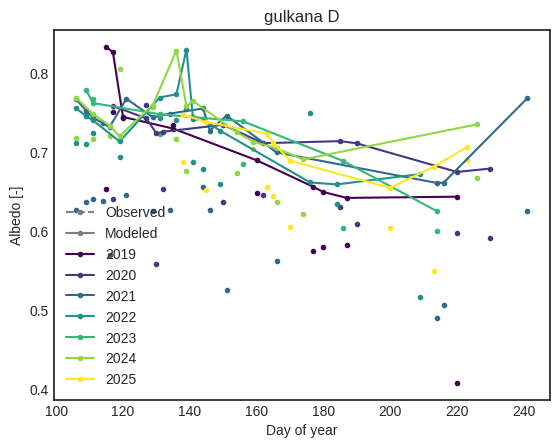

In [19]:
glacier = 'wolverine'
site = 'B'
date = '03_12'

all_mod_albedo = []
all_meas_albedo = []
best_dict = {}
all_best = {}
for glacier in ['gulkana']: # site_dict:
    best_dict[glacier] = {}
    all_best[glacier] = {}
    for site in 'D': # site_dict[glacier]:
        fp = base_fp + f'{date}_{glacier}_{site}_0/'

        if not os.path.exists(fp + 'missing.txt'):
            print(f'! no missing.txt in {glacier} {site}; simulations could be in progress !')
            pass
        fn = f'grid_{date}_setXX_run0_0.nc'

        min_error = np.inf
        by_params = {}
        for setno in range(2, 30, 5):
            fn_set = fp + fn.replace('XX', str(setno))
            if not os.path.exists(fn_set):
                continue

            mb_data = MassBalance(glacier, site, use='benchmark')
            albedo_data = Albedo(glacier, site)

            ds = xr.open_dataset(fn_set)
            # mb_data.get_model_mb(ds)
            # if mb_data.dataset == 'seasonal':
            #     mae_summer, mae_winter = mb_data.mae(True)
            #     mae_mb = mae_summer + mae_winter 
            # else:
            #     mae_mb = mb_data.mae()
            
            albedo_data.get_model_albedo(ds)
            mae_albedo = albedo_data.mae()

            if ds.attrs['ksp_BC'] not in by_params:
                by_params[ds.attrs['ksp_BC']] = {}
            by_params[ds.attrs['ksp_BC']][ds.attrs['C1']] = albedo_data 

            error = mae_albedo # * 2 + mae_mb
            if error < min_error:
                min_error = error 
                best_set = (ds.attrs['ksp_BC'], ds.attrs['C1'], fn_set)
                best_ds = ds.copy(deep=True)

        mb_data = MassBalance(glacier, site, use='benchmark')
        albedo_data = Albedo(glacier, site)
        best_dict[glacier][site] = best_ds
        all_best[glacier][site] = {'ksp_BC':best_set[0], 'C1':best_set[1]}

        # parse model run
        albedo_data.get_model_albedo(best_ds)
        # mb_data.get_model_mb(best_ds)
        
        print(best_ds.attrs['glacier'], best_ds.attrs['site'])
        print(best_set)
        print('Albedo bias:',albedo_data.bias())
        # if mb_data.dataset == 'seasonal':
        #     me_summer, me_winter = mb_data.bias(True)
        #     print('Summer mass balance bias:',me_summer)
        #     print('Winter mass balance bias:',me_winter)
        # else:
        #     print('Annual mass balance bias:',mb_data.mae())

        # plot
        # mb_data.plot_mb()
        albedo_data.plot_timeseries()

        for mod, meas in zip(albedo_data.mod, albedo_data.meas):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)

(<Figure size 500x340 with 4 Axes>, array([<Axes: >, <Axes: >], dtype=object))

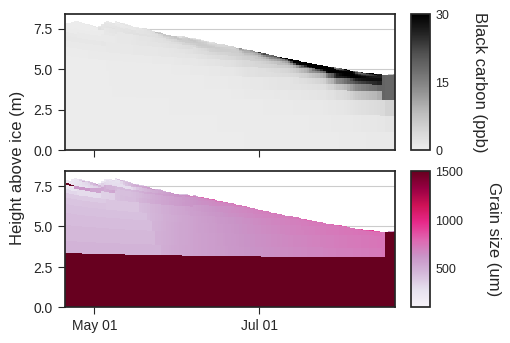

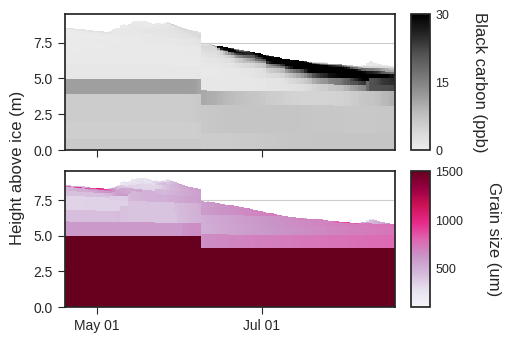

In [20]:
ds = best_dict['gulkana']['D']
dates = pd.date_range('2019-04-20','2019-08-20')
visualize_layers(ds, dates, ['layerBC','layergrainsize'])
visualize_layers(ds, dates+pd.Timedelta(days=365*3), ['layerBC','layergrainsize'])

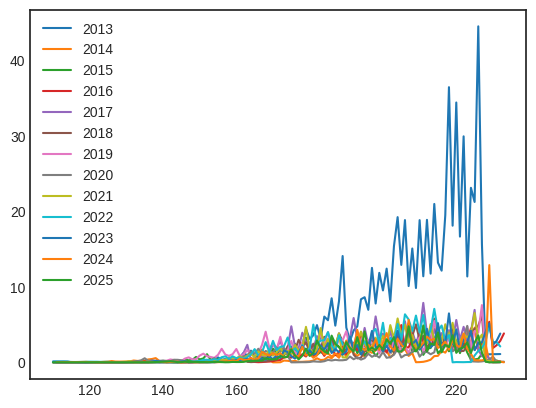

In [11]:
ds = best_dict['gulkana']['D']
for year in np.unique(pd.to_datetime(ds.time.values).year):
    dates = pd.date_range(f'{year}-04-20',f'{year}-08-20')
    dsk = ds.sel(time=dates)
    plt.plot(pd.to_datetime(dsk.time.values).day_of_year, dsk.layerdust.isel(layer=0), label=str(year))
plt.legend()
plt.show()

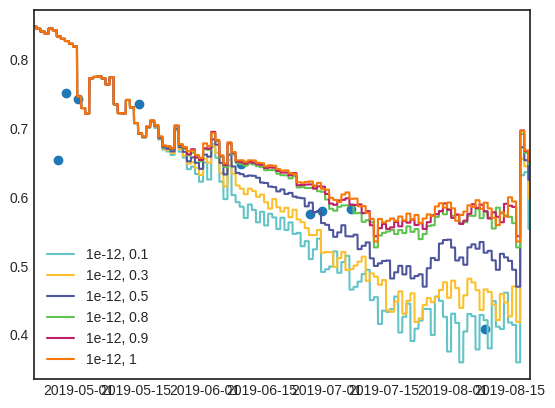

In [26]:
# al = Albedo('gulkana','D')
# ds = xr.open_dataset('../../Output/gulkanaD_2026_03_11_4.nc')
# al.get_model_albedo(ds)
# al.plot_timeseries()
# ds = best_dict['gulkana']['D']
# dates = pd.date_range('2019-04-20','2019-08-20')
# visualize_layers(ds, dates, ['layerwater','layergrainsize'])
for setno in range(2, 30, 5):
    fn_set = fp + fn.replace('XX', str(setno))
    if not os.path.exists(fn_set):
        continue
    ds = xr.open_dataset(fn_set).sel(time=slice('2019-04-20','2019-08-20'))
    plt.plot(ds.time, ds.albedo, label=ds.attrs['C1']+', '+ds.attrs['ksp_BC'], c=colors[setno//5])

    # if ds.attrs['C1'] == '1e-12' and ds.attrs['ksp_BC'] == '0.5':
    #     dates = pd.date_range('2019-04-20','2019-08-20')
    #     visualize_layers(ds, dates, ['layerwater','layergrainsize'])
plt.scatter(albedo_data.time, albedo_data.meas)
plt.xlim(pd.to_datetime('2019-04-20'), pd.to_datetime('2019-08-20'))
plt.legend()
plt.show()

In [12]:
all_best

{'wolverine': {'EC': {'ksp_BC': '0.9', 'C1': '1e-10'}}}

In [ ]:
import pickle
with open('best_datasets.pkl','wb') as f:
    pickle.dump(all_best, f)

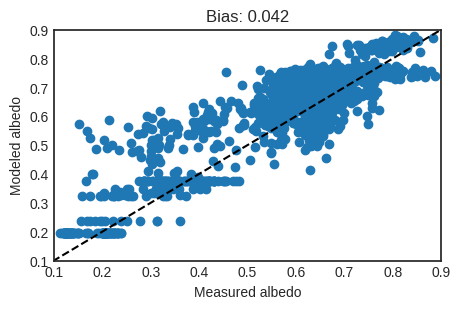

In [7]:
plt.figure(figsize=(5,3))
plt.scatter(all_meas_albedo, all_mod_albedo, label='Data')
plt.plot([0,1], [0,1], 'k--',label='1:1')
plt.xlim(0.1, 0.9)
plt.ylim(0.1, 0.9)
plt.xlabel('Measured albedo')
plt.ylabel('Modeled albedo')
bias = np.nanmean(np.array(all_mod_albedo) - np.array(all_meas_albedo))
plt.title(f'Bias: {bias:.3f}')
plt.show()

In [8]:
all_df = None
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']

    dsu = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
    dsv = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
    wind = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    dsv.values = wind 
    all_wind = dsv.resample(time='d').mean()
    # glac_qms = {'taku':'lemon_creek','kennicott':'gulkana'}
    # glac_qm = glac_qms[glacier] if glacier in glac_qms else glacier
    # df_qm = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_{glac_qm}_wind.csv')
    # adj = np.interp(values, df_qm['sorted'], df_qm['mapping'])
    # dsv.values = adj 
    # wind = dsv.resample(time='d').mean()

    for site in site_dict[glacier]:
        # albedo = Albedo(glacier, site)
        ds = best_dict[glacier][site]
        # albedo.get_model_albedo(ds)
        # albedo.plot_timeseries()
        out = base_fp+f'ddf/{glacier}{site}_df.csv'
        df = get_ddf_df(ds, ds_bc,  n_rolling_bc=5, n_rolling_pdds=1, savefig=True) # output_fn=out, plot_corr=True,
        df['glacier'] = [glacier] * len(df.index)
        df['glaciersite'] = [glacier + site] * len(df.index)
        df['wind'] = all_wind.sel(time=pd.to_datetime(df.index)).values 
        if all_df is not None:
            all_df = pd.concat([all_df, df])
        else:
            all_df = df

/trace/home/cvwilson/miniconda3/envs/eb_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


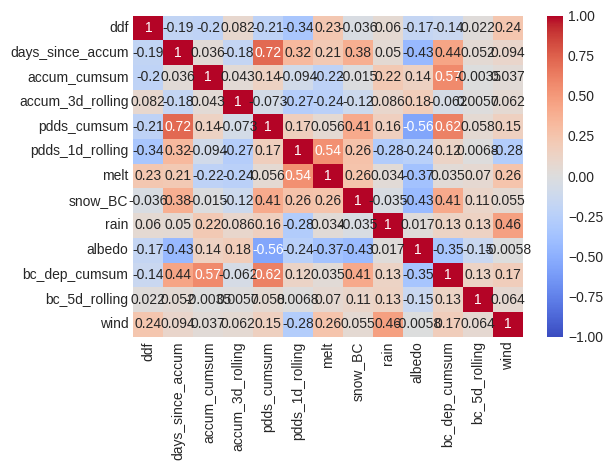

In [9]:
corr = all_df.drop(columns=['glaciersite','glacier']).corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

In [9]:
import statsmodels.api as sm
# df['BC_eff'] = df['bc_1d_rolling'].ewm(halflife=3).mean()

# df must contain columns: 'melt', 'PDD', 'BC'
X = df[['pdds_1d_rolling', 'bc_5d_rolling','wind']]
y = df['melt']

model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   melt   R-squared (uncentered):                   0.944
Model:                            OLS   Adj. R-squared (uncentered):              0.944
Method:                 Least Squares   F-statistic:                              5273.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):                        0.00
Time:                        11:20:01   Log-Likelihood:                         -2454.4
No. Observations:                 942   AIC:                                      4915.
Df Residuals:                     939   BIC:                                      4929.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

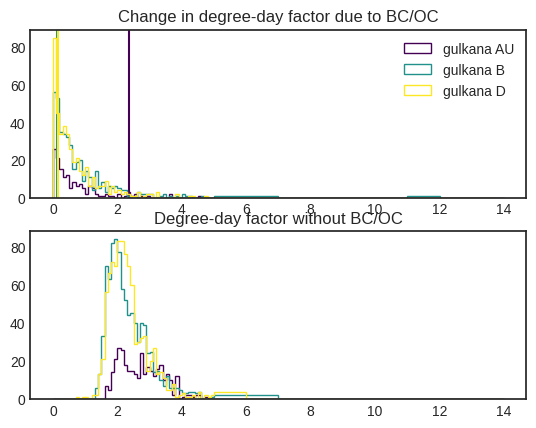

In [16]:
bins= np.concatenate([np.arange(0,5,0.1), np.arange(5, 15, 1)])
fig, (ax1, ax2) = plt.subplots(2)
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=0, vmax=2)

i=0
for glacier in ['gulkana']:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
    for site in site_dict[glacier]:
        ds_base = best_dict[glacier][site]
        df_base = get_ddf_df(ds_base, ds_bc, n_rolling_pdds=1)

        ds_noBCOC = xr.open_dataset(base_fp + 'ddf/' + glacier + site + '_2026_03_09_noBCOC_0.nc')
        df_noBCOC = get_ddf_df(ds_base, ds_bc, n_rolling_pdds=1)

        f_snow = df_base['ddf'].copy()
        fBC = (df_noBCOC['melt'] - f_snow*df_noBCOC['pdds_1d_rolling']) / (df_noBCOC['pdds_1d_rolling'])
        ax1.hist(fBC.values, bins=bins, histtype='step', edgecolor=cmap(norm(i)), label=glacier+' '+site)# colors[3])
        ax1.axvline(np.nanmean(fBC.values),color=cmap(norm(i)))
        ax1.set_title('Change in degree-day factor due to BC/OC')

        ax2.hist(f_snow, bins=bins, histtype='step', edgecolor=cmap(norm(i)))
        ax2.set_title(f'Degree-day factor without BC/OC')
        
        i+= 1
ax1.legend()
plt.show()